In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
import string, random

2025-06-18 05:33:15.955743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750224796.158226      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750224796.215317      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Load Handwritten Dataset (EMNIST Letters)
def load_handwritten():
    (ds_train, _), _ = tfds.load(
        'emnist/letters',
        split=['train', 'test'],
        shuffle_files=True,
        as_supervised=True,
        with_info=True
    )
    X_hand = []
    for img, label in tfds.as_numpy(ds_train.take(20000)):
        X_hand.append(img)
    return np.array(X_hand)

In [4]:
# Generate Printed Dataset
def generate_printed_dataset(num_samples=20000, img_size=28):
    X_print = []
    characters = list(string.ascii_uppercase)
    for _ in range(num_samples):
        img = Image.new('L', (img_size, img_size), color=255)
        draw = ImageDraw.Draw(img)
        font = ImageFont.load_default()
        char = random.choice(characters)
        draw.text((5, 5), char, fill=0, font=font)
        X_print.append(np.array(img))
    return np.array(X_print)

X_hand = load_handwritten()
X_print = generate_printed_dataset()

y_hand = np.ones(X_hand.shape[0])
y_print = np.zeros(X_print.shape[0])
X_print = X_print.reshape(-1, 28, 28, 1)  # Make X_print 4D like X_hand

X = np.concatenate([X_hand, X_print], axis=0).astype('float32') / 255.0
X = X.reshape(-1, 28, 28, 1)
y = np.concatenate([y_hand, y_print], axis=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=128)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


I0000 00:00:1750225041.318273     103 service.cc:148] XLA service 0x79090c007db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750225041.318877     103 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750225041.318899     103 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750225041.587775     103 cuda_dnn.cc:529] Loaded cuDNN version 90300


 38/225 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9373 - loss: 0.2422

I0000 00:00:1750225043.666759     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9849 - loss: 0.0659 - val_accuracy: 1.0000 - val_loss: 2.4045e-06
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 2.0471e-06 - val_accuracy: 1.0000 - val_loss: 1.6567e-06
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 1.2723e-06 - val_accuracy: 1.0000 - val_loss: 1.0897e-06
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 7.9050e-07 - val_accuracy: 1.0000 - val_loss: 8.6568e-07
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 6.8643e-07 - val_accuracy: 1.0000 - val_loss: 6.7266e-07
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 6.0599e-07 - val_accuracy: 1.0000 - val_loss: 4.7880e-07
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 3.1616e-07 - val_accuracy: 1.0000 - val_loss: 3.8162e-07
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy:

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.0000 - loss: 6.0891e-07
Test Accuracy: 1.0000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


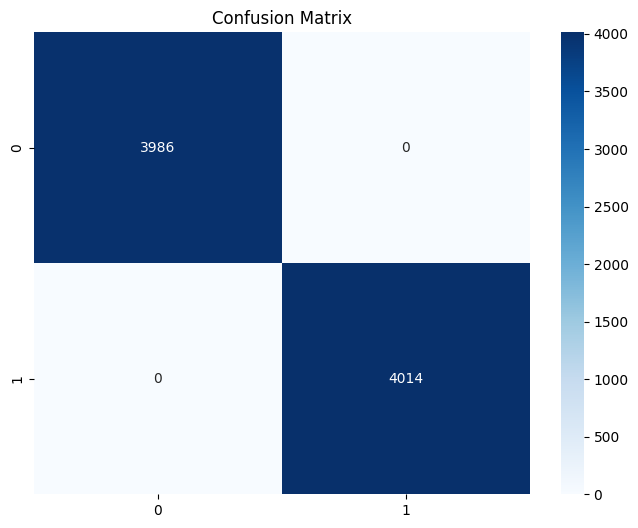

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3986
         1.0       1.00      1.00      1.00      4014

    accuracy                           1.00      8000
   macro avg       1.00      1.00      1.00      8000
weighted avg       1.00      1.00      1.00      8000



In [5]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))

In [8]:
model.save("handwritten_vs_printed_classifier.h5")